# Image Restoration — Final Project (Computer Vision)

**Course:** Fundamentals of Computer Vision (Dr. Seifipour)
**Task:** Restore damaged photographs (noise, scratches, color loss) using a supervised deep-learning model trained on paired damaged/clean images from the `joshuachin/openphoto-restore-dataset`.

**Architecture choice:** U-Net.
U-Net is a strong default for image restoration/translation tasks because:
- The encoder-decoder structure with **skip connections** lets fine spatial details (edges, texture) from the input bypass the bottleneck and reach the decoder directly, which a plain Autoencoder cannot do — this is critical for restoration, where the output must stay pixel-aligned with the input.
- It works well with relatively small datasets since it doesn't need an adversarial signal (unlike a GAN) or a probabilistic latent space (unlike a VAE) to train stably.
- It's fully convolutional, so it naturally outputs an image the same size as the input.

Fill in your group's names and student IDs below before submitting.

*Group members:* `<Abbas Khoshdooni Farahani>` (`<810101415>`), `<Deniz Mostafazadeghan>` (`<810102603>`), `<Sajjad Taghizade>` (`<810102425>`)


## 0. Setup

In [1]:
# If running in a fresh environment (e.g. Colab), uncomment the installs below.
# !pip install -q datasets hf_xet torch torchvision scikit-image matplotlib pandas tqdm

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Paths (edit if you save/load checkpoints or outputs locally) ----
OUTPUT_DIR = "./outputs"
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Using device: cuda


## 1. Data Preparation

Steps performed here:
1. Load the dataset from Hugging Face Hub.
2. Resize damaged/clean image pairs to a fixed size (256x256).
3. Normalize pixel values to `[0, 1]` (and optionally to `[-1, 1]` if your final activation is `tanh`).
4. Split into train / validation / test.
5. Wrap everything in a `Dataset` + `DataLoader`.


In [2]:
from datasets import load_dataset

# The dataset already ships with 'train' and 'test' splits (see project description).
# We further split 'train' into train/validation.
raw_data = load_dataset("joshuachin/openphoto-restore-dataset")

print(raw_data)
print("Example keys:", raw_data["train"][0].keys())


README.md:   0%|          | 0.00/6.25k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/451M [00:00<?, ?B/s]

data/train-00003-of-00009.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

...

data/train-00008-of-00009.parquet:   0%|          | 0.00/440M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pristine_image', 'damaged_image'],
        num_rows: 4500
    })
    test: Dataset({
        features: ['pristine_image', 'damaged_image'],
        num_rows: 500
    })
})
Example keys: dict_keys(['pristine_image', 'damaged_image'])


In [3]:
IMAGE_SIZE = 256  # can be lowered to e.g. 128 to speed up experimentation

# Basic transform: resize + convert to tensor in [0, 1].
# (Normalizing to [0,1] is sufficient for an MSE/L1-trained restoration model with a sigmoid output head.)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # scales PIL image [0,255] -> tensor [0,1]
])


class RestorationDataset(Dataset):
    """Wraps a HuggingFace dataset split of (damaged, clean) image pairs.

    Expects each example to expose the damaged input image and the ground-truth
    clean image. Adjust the two column names below ('input' / 'ground_truth')
    to whatever the dataset actually calls them if different.
    """

    INPUT_COL = "damaged_image"   # damaged image column name
    TARGET_COL = "pristine_image" # clean / ground-truth image column name

    def __init__(self, hf_split, transform=None):
        self.data = hf_split
        self.transform = transform or base_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]
        damaged = example[self.INPUT_COL].convert("RGB")
        clean = example[self.TARGET_COL].convert("RGB")

        damaged = self.transform(damaged)
        clean = self.transform(clean)
        return damaged, clean


# Sanity-check the actual column names before wrapping the dataset; the dataset card
# may use different keys (e.g. 'damaged'/'clean' or 'image'/'label'). Update the
# class attributes above if this print does not show two PIL Image columns.
print(raw_data["train"].features)


{'pristine_image': Image(mode=None, decode=True), 'damaged_image': Image(mode=None, decode=True)}


In [4]:
full_train = RestorationDataset(raw_data["train"], transform=base_transform)
test_dataset = RestorationDataset(raw_data["test"], transform=base_transform)

# Split the train split into train/validation (90/10)
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 4050 | Val: 450 | Test: 500


Damaged batch shape: torch.Size([16, 3, 256, 256])
Clean batch shape: torch.Size([16, 3, 256, 256])


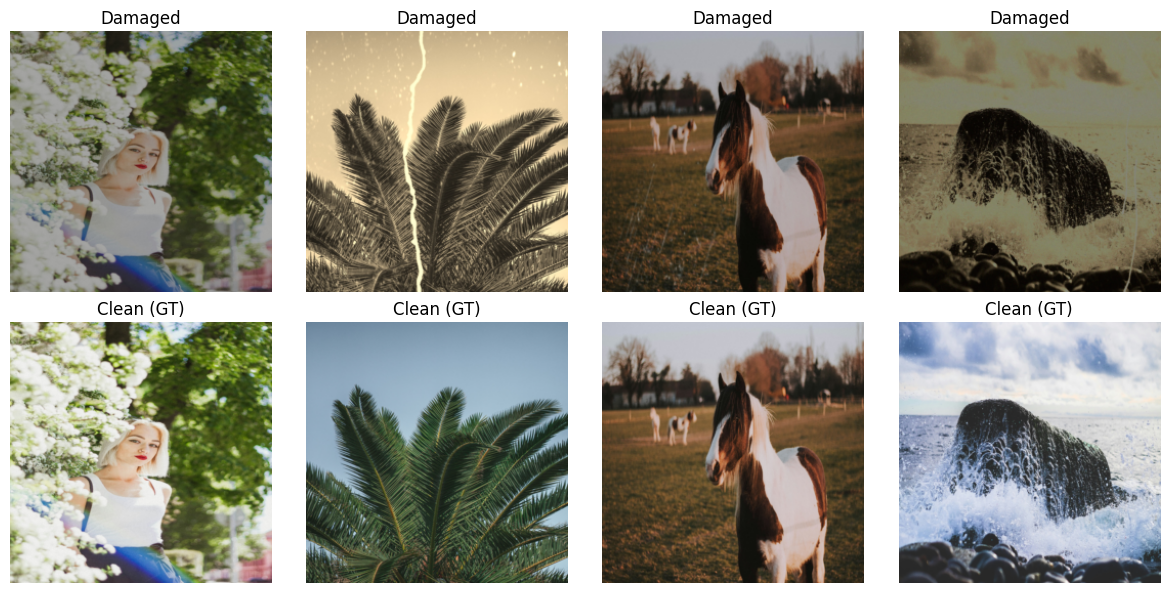

In [5]:
BATCH_SIZE = 16
NUM_WORKERS = 0  # bump to 2+ only after confirming training runs; multiprocessing workers can stall in Colab/Jupyter

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Quick visual sanity check of one batch
damaged_batch, clean_batch = next(iter(train_loader))
print("Damaged batch shape:", damaged_batch.shape)
print("Clean batch shape:", clean_batch.shape)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(damaged_batch[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title("Damaged")
    axes[0, i].axis("off")
    axes[1, i].imshow(clean_batch[i].permute(1, 2, 0).numpy())
    axes[1, i].set_title("Clean (GT)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 2. Model: U-Net

A compact U-Net for image restoration:
- **Encoder**: 4 downsampling stages (Conv-BN-ReLU x2 + MaxPool), doubling channels each stage.
- **Bottleneck**: deepest, most compressed representation.
- **Decoder**: 4 upsampling stages (transposed conv) that concatenate the corresponding encoder feature map (skip connection) before two more conv layers.
- **Output head**: 1x1 conv back to 3 channels + `sigmoid`, since inputs are normalized to `[0, 1]`.

Skip connections are the key advantage over a plain Autoencoder for this task: they let the network preserve fine spatial detail instead of forcing everything through a single narrow bottleneck.


In [6]:
class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Standard U-Net for image-to-image restoration (input size preserved)."""

    def __init__(self, in_channels=3, out_channels=3, base_ch=64):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.enc3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.enc4 = DoubleConv(base_ch * 4, base_ch * 8)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_ch * 8, base_ch * 16)

        # Decoder
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_ch * 16, base_ch * 8)

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_ch * 8, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder + skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d1))  # keep output in [0, 1]
        return out


model = UNet(in_channels=3, out_channels=3, base_ch=64).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {num_params:,}")


U-Net parameters: 31,043,651


## 3. Training Setup

- **Loss:** L1 loss (mean absolute error). L1 tends to produce sharper restorations than MSE (less over-smoothing), but MSE is provided as an easy swap.
- **Optimizer:** Adam.
- **Hyperparameters:** learning rate, batch size, epochs, input size are all defined in one place below so they're easy to report in the write-up.


In [7]:
# ---- Hyperparameters (report these in your write-up) ----
LEARNING_RATE = 1e-4
NUM_EPOCHS = 30
LOSS_FN_NAME = "L1"          # "L1" or "MSE"
INPUT_IMAGE_SIZE = IMAGE_SIZE
HARDWARE = str(device)

criterion = nn.L1Loss() if LOSS_FN_NAME == "L1" else nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print({
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "loss_fn": LOSS_FN_NAME,
    "image_size": INPUT_IMAGE_SIZE,
    "hardware": HARDWARE,
})


{'learning_rate': 0.0001, 'num_epochs': 30, 'batch_size': 16, 'loss_fn': 'L1', 'image_size': 256, 'hardware': 'cuda'}


In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Runs one epoch. If optimizer is given, trains; otherwise, evaluates only."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=("train" if is_train else "val"), leave=False)
    with context:
        for damaged, clean in pbar:
            damaged = damaged.to(device, non_blocking=True)
            clean = clean.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            output = model(damaged)
            loss = criterion(output, clean)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = damaged.size(0)
            total_loss += loss.item() * batch_size
            n_samples += batch_size
            pbar.set_postfix(loss=loss.item())

    return total_loss / n_samples


In [9]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "unet_best.pt")

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Training"):
    train_loss = run_epoch(model, train_loader, criterion, optimizer)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_ckpt_path)

print(f"Best validation loss: {best_val_loss:.4f} (saved to {best_ckpt_path})")


Training:   0%|          | 0/30 [00:00<?, ?it/s]

train:   0%|          | 0/254 [00:00<?, ?it/s]

val:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 001/30 | train_loss=0.1020 | val_loss=0.0731


train:   0%|          | 0/254 [00:00<?, ?it/s]

...

val:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 029/30 | train_loss=0.0577 | val_loss=0.0549


train:   0%|          | 0/254 [00:00<?, ?it/s]

val:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 030/30 | train_loss=0.0579 | val_loss=0.0554
Best validation loss: 0.0548 (saved to ./checkpoints/unet_best.pt)


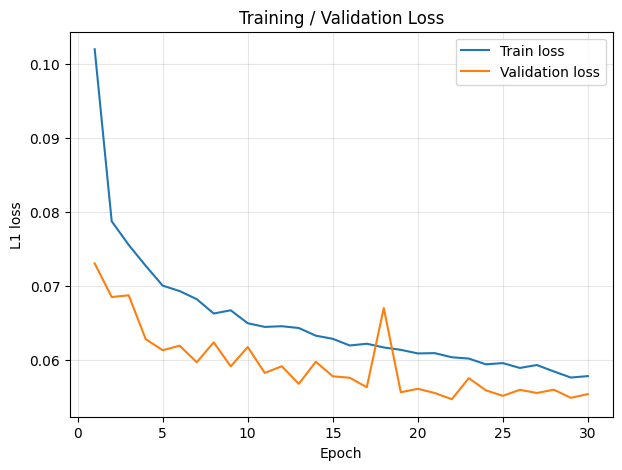

In [10]:
# ---- Loss curves ----
plt.figure(figsize=(7, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel(f"{LOSS_FN_NAME} loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()


## 4. Evaluation (PSNR / SSIM / MSE / MAE)

Load the best checkpoint and evaluate on the held-out test set.


In [11]:
# Load best checkpoint before final evaluation
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model.eval()


def to_numpy_img(t):
    """CHW tensor in [0,1] -> HWC numpy array in [0,1], float64 for skimage metrics."""
    return t.detach().cpu().permute(1, 2, 0).numpy().astype(np.float64)


@torch.no_grad()
def evaluate(model, loader):
    mse_list, mae_list, psnr_list, ssim_list = [], [], [], []

    for damaged, clean in tqdm(loader, desc="Evaluating"):
        damaged = damaged.to(device)
        clean_gpu = clean.to(device)

        output = model(damaged)

        # Per-image metrics (skimage needs numpy arrays, computed per sample)
        for i in range(output.size(0)):
            out_np = to_numpy_img(output[i])
            gt_np = to_numpy_img(clean[i])

            mse = np.mean((out_np - gt_np) ** 2)
            mae = np.mean(np.abs(out_np - gt_np))
            psnr = sk_psnr(gt_np, out_np, data_range=1.0)
            ssim = sk_ssim(gt_np, out_np, data_range=1.0, channel_axis=2)

            mse_list.append(mse)
            mae_list.append(mae)
            psnr_list.append(psnr)
            ssim_list.append(ssim)

    return {
        "MSE": float(np.mean(mse_list)),
        "MAE": float(np.mean(mae_list)),
        "PSNR (dB)": float(np.mean(psnr_list)),
        "SSIM": float(np.mean(ssim_list)),
    }


test_metrics = evaluate(model, test_loader)

results_table = pd.DataFrame([test_metrics])
results_table.index = ["U-Net (test set)"]
print(results_table.to_string())
results_table.to_csv(os.path.join(OUTPUT_DIR, "test_metrics.csv"))

# Quick pass/fail check against the project's minimum acceptable performance
print("\nMinimum required: PSNR >= 20 dB, SSIM >= 0.65")
print(f"PSNR OK: {test_metrics['PSNR (dB)'] >= 20}")
print(f"SSIM OK: {test_metrics['SSIM'] >= 0.65}")


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

                       MSE       MAE  PSNR (dB)      SSIM
U-Net (test set)  0.007951  0.057866  22.996637  0.862606

Minimum required: PSNR >= 20 dB, SSIM >= 0.65
PSNR OK: True
SSIM OK: True


## 5. Visualization — Damaged / Ground Truth / Restored

Show at least 5 test examples, each with three images side by side.


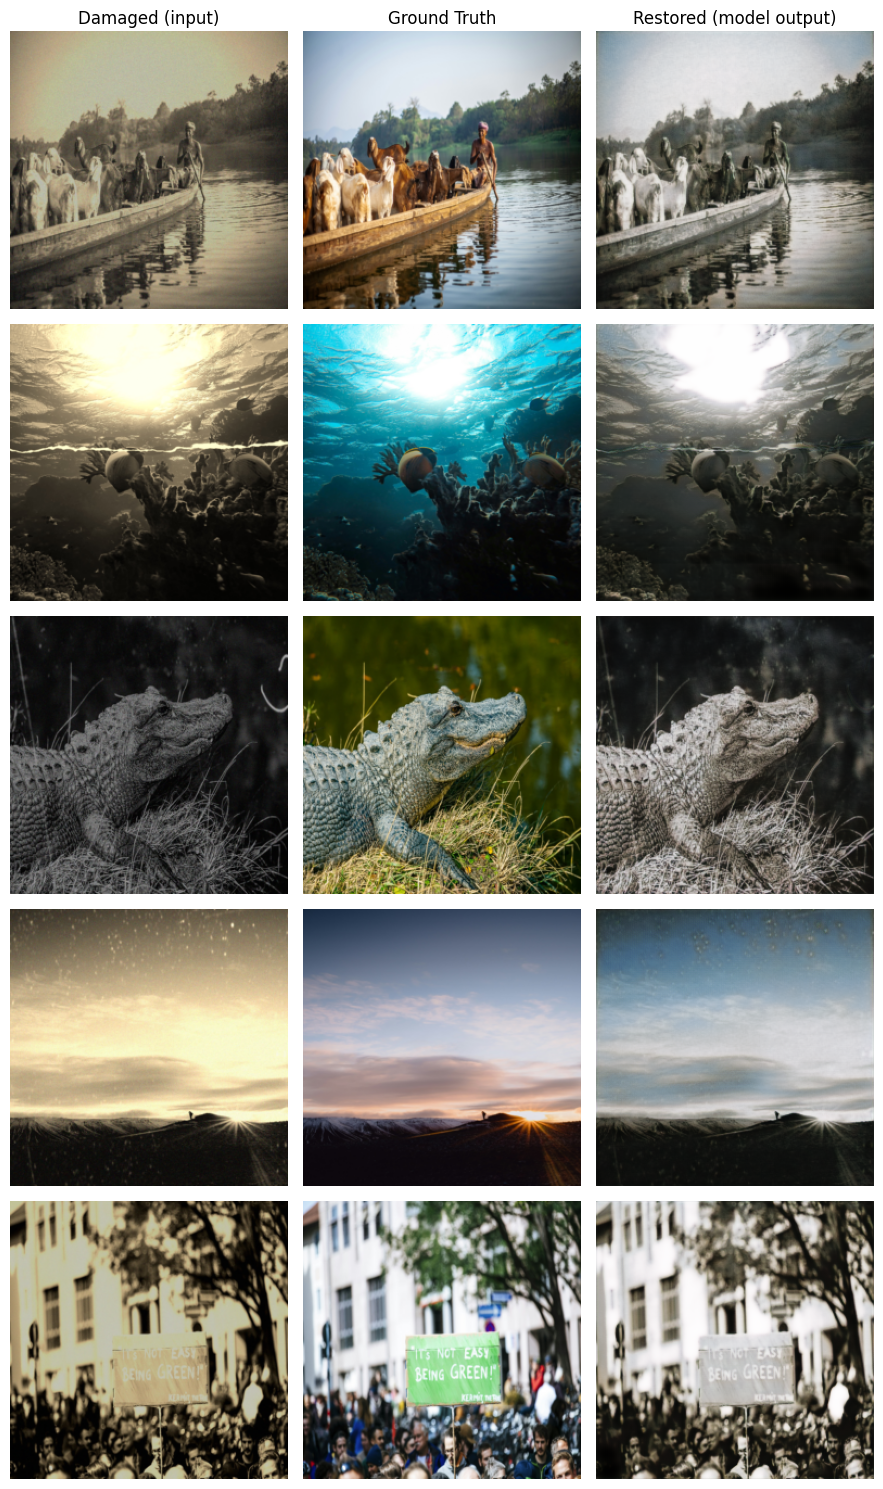

In [12]:
@torch.no_grad()
def show_examples(model, dataset, n=5, seed=0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[None, :]

    col_titles = ["Damaged (input)", "Ground Truth", "Restored (model output)"]

    for row, idx in enumerate(indices):
        damaged, clean = dataset[idx]
        output = model(damaged.unsqueeze(0).to(device)).squeeze(0)

        images = [damaged, clean, output.cpu()]
        for col in range(3):
            img = images[col].permute(1, 2, 0).numpy()
            axes[row, col].imshow(np.clip(img, 0, 1))
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(col_titles[col])

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "sample_restorations.png"), dpi=150, bbox_inches="tight")
    plt.show()


show_examples(model, test_dataset, n=5)
